# LKIPA Resonance v.s. Temperature Analysis
---




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

# Reload credentials module to get latest changes
import importlib

# # Import scripts for JPA AND LKIPA planck spectroscopy
# import JPA_planck_spec as jps
# import LKIPA_planck_spec as lps
import LKIPA_resonance_PSD as psd
importlib.reload(psd)

<module 'LKIPA_resonance_PSD' from 'c:\\Users\\Admin\\Desktop\\Jai Data\\Presto-Measurement-Scripts\\Planck\\LKIPA_resonance_PSD.py'>

## 1. Extract all fitting parameters for each temperature
---

### TEST

### 1.1. Define function to open hdf5 files

In [2]:
# Load experiment data
def load_time_series_data(file_):
    with h5py.File(file_, "r") as dataset:
        run_key = list(dataset.keys())[0]   # this is your myrun
        grp = dataset[run_key]

        return {
            "run": run_key,
            "sample": grp["sample"][()],
            "df": np.asarray(grp["df"]),
            "time_series": np.asarray(grp["Time Series Data"]),
            "dt": np.asarray(grp["dt"]),
            "n_pix": np.asarray(grp["Pixels"]),
            "n_samples": np.asarray(grp["Samples per pixel"]),
            "temp": np.asarray(grp["Temperature"]),
            "fit_params": np.asarray(grp["Fit parameters"]),
        }

### 1.2. Extract sample file

In [7]:
file = "D:/Planck Spectroscopy 2026-03/LKIPA Resonance/LKIPA_resonance_PSD_144.9mk.hdf5"
data_test = load_time_series_data(file)


### 1.3 Get PSD

Data format: Mixed mode (I and Q interleaved)
Shape of I data: (1000, 100000)

FITTING PARAMETERS:
A_background =  1.09
B_background =  -0.3
A_peak =  0.17
f0 =  4.42978 GHz
gamma =  0.535 MHz


C:\Users\Admin\AppData\Local\Temp\ipykernel_12076\4199658011.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  temp_str = str(int(np.round(data_test["temp"], 2)))


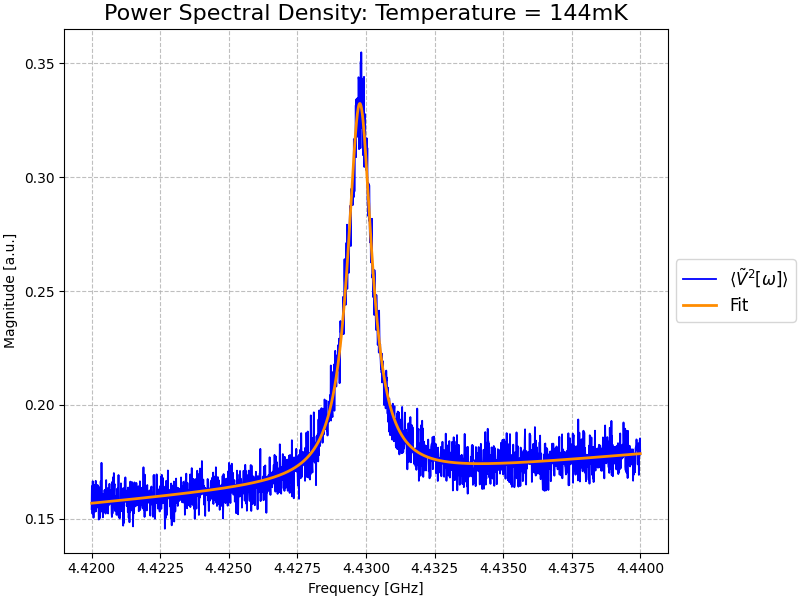

In [8]:
# Get untwisted dc removed time series
I_all = psd.remove_DC(data_all=data_test["time_series"])

# GET POWER SPECTRAL DENSITY
PSD_avg, f_arr, t_arr = psd.get_PSD_avg(
    I_all=I_all,
    n_samples=int(np.real(data_test["n_samples"])),
    dt=data_test["dt"]
)

# SELECT BANDWIDTH
PSD_bw, f_bw = psd.get_PSD_bw(
    PSD_avg=PSD_avg,
    f_arr=f_arr,
    f_L=0.42,
    f_R=0.44,
)

# Get fitting parameters for PSD
fit_params = psd.lorentz_fit(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw,
    lorentzian_fit_func=psd.lorentzian_fit_func,
)

# Plotting
# get fitting function
fit_func = psd.lorentzian_fit_func(
    f_bw, 
    A_bg=fit_params[0],
    B_bg=fit_params[1],
    A_peak=fit_params[2],
    f_0=fit_params[3],
    gamma=fit_params[4]
)

# temperature string
temp_str = str(int(np.round(data_test["temp"], 2)))

# PLOT
# ====
fig, ax = plt.subplots(
    constrained_layout=True, 
    figsize=(8, 6)
    )

# Plot PSD
ax.grid(alpha=0.8, linestyle='--')
ax.plot(4 + f_bw, PSD_bw, label="$\\langle \\tilde V^2[\\omega] \\rangle$", color = "b", lw=1.3)
ax.plot(
    4 + f_bw, 
    fit_func,
    label='Fit',
    lw=2,
    color='darkorange'
    )
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Magnitude [a.u.]")
ax.set_title("Power Spectral Density: Temperature = " + temp_str+ 'mK', fontsize=16)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

plt.show()

----

### 1.1 Loop over hdf5 files


In [9]:
folder = "D:/Planck Spectroscopy 2026-03/LKIPA Resonance"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

fitting_params_list = []
temp_list = []

for file in files:
    data_test = load_time_series_data(file)
    temp_str = str(int(np.round(data_test["temp"], 2)))

    # Only need to fit when the previous fitting failed
    if data_test["fit_params"][2] >= 0.15 and data_test["fit_params"][2] <= 0.2:
        fitting_params_list.append(data_test["fit_params"])
        temp_list.append(temp_str)
        continue

    else:
        print(f"Fitting for temperature {temp_str} mK")

        # Get untwisted dc removed time series
        I_all = psd.remove_DC(data_all=data_test["time_series"])

        # GET POWER SPECTRAL DENSITY
        PSD_avg, f_arr, t_arr = psd.get_PSD_avg(
            I_all=I_all,
            n_samples=int(np.real(data_test["n_samples"])),
            dt=data_test["dt"]
        )

        # SELECT BANDWIDTH
        PSD_bw, f_bw = psd.get_PSD_bw(
            PSD_avg=PSD_avg,
            f_arr=f_arr,
            f_L=0.42,
            f_R=0.44,
        )

        # Get fitting parameters for PSD
        fit_params = psd.lorentz_fit(
            PSD_bandwidth=PSD_bw,
            f_arr_bandwidth=f_bw,
            lorentzian_fit_func=psd.lorentzian_fit_func,
        )
        # Append fitting parameters and temperature to lists
        temp_list.append(temp_str)
        fitting_params_list.append(fit_params)

OSError: [Errno 22] Unable to synchronously open file (file read failed: time = Wed Apr  1 11:15:03 2026
, filename = 'D:/Planck Spectroscopy 2026-03/LKIPA Resonance\LKIPA_resonance_PSD_20.97mk.hdf5', file descriptor = 6, errno = 22, error message = 'Invalid argument', buf = 0000002C381ED3B0, total read size = 8, bytes this sub-read = 8, offset = 0)